In [1]:
!pip install xgboost lightgbm scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 11.7 MB/s eta 0:00:09
   - -------------------------------------- 3.9/101.7 MB 11.5 MB/s eta 0:00:09
   -- ------------------------------------- 6.3/101.7 MB 11.2 MB/s eta 0:00:09
   -- ------------------------------------- 7.6/101.7 MB 9.9 MB/s eta 0:00:10
   --- ------------------------------------ 8.7/101.7 MB 8.9 MB/s eta 0:00:11
   --- ------------------------------------ 9.2/101.7 MB 8.2 MB/s eta 0:00:12
   --- ------------------------------------ 10.0/101.7 MB 6.9 MB/s eta 0:00:14
   ---- ----------------------------------- 10.5/101.7 MB 6.5 MB/s eta 0:00:15
   ---- ----------------------------------- 11.3/101.7 MB 6.2 MB/s eta 0:00:15
   ---- ----------------------------------- 12.3/101.7 MB 6.0 MB/s eta 0:00:15
   ---- ----------------------------------- 12.6/101.7 MB 5.9 MB


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\wizar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [17]:
import numpy as np
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

import xgboost as xgb
import lightgbm as lgb

PROCESSED_DIR = "./data/processed"
MODELS_DIR    = "./data/models"
os.makedirs(MODELS_DIR, exist_ok=True)

print("Imports ready")
print(f"XGBoost  version : {xgb.__version__}")
print(f"LightGBM version : {lgb.__version__}")

Imports ready
XGBoost  version : 3.2.0
LightGBM version : 4.6.0


In [18]:
def load_splits(name: str) -> dict:
    path = os.path.join(PROCESSED_DIR, f"{name}_features.pkl")
    with open(path, "rb") as f:
        data = pickle.load(f)
    print(f"Loaded '{name}':")
    print(f"  X_train : {data['X_train'].shape}")
    print(f"  X_val   : {data['X_val'].shape}")
    print(f"  X_test  : {data['X_test'].shape}")
    print(f"  Features: {len(data['feature_cols'])}")
    return data

btc = load_splits("btc")
eth = load_splits("eth")

feature_cols = btc["feature_cols"]

print(f"\nFeature list: {feature_cols}")

Loaded 'btc':
  X_train : (12200, 31)
  X_val   : (2614, 31)
  X_test  : (2615, 31)
  Features: 31
Loaded 'eth':
  X_train : (12198, 31)
  X_val   : (2614, 31)
  X_test  : (2614, 31)
  Features: 31

Feature list: ['return_1', 'return_3', 'return_6', 'return_12', 'return_24', 'ema_9_21_cross', 'ema_21_50_cross', 'price_vs_ema21', 'price_vs_ema50', 'macd', 'macd_signal', 'macd_hist', 'rsi_7', 'rsi_14', 'rsi_21', 'rsi_divergence', 'roc_6', 'roc_12', 'roc_24', 'bb_width', 'bb_position', 'atr_pct', 'vol_ratio', 'obv_zscore', 'ema_21_4h', 'rsi_14_4h', 'trend_4h', 'macd_hist_4h', 'bull_regime', 'rsi_14_1d', 'daily_atr_pct']


In [19]:
#4
# Before training, always check how balanced your BUY vs HOLD labels are.
# Severely imbalanced datasets cause the model to just predict the majority class.
# If BUY% is below 30% or above 70%, we need to handle it.

def check_balance(data: dict, name: str):
    labels = {0: "SELL", 1: "HOLD", 2: "BUY"}
    for split in ["train", "val", "test"]:
        y     = data[f"y_{split}"]
        total = len(y)
        print(f"  {name} {split:5s} (n={total:,}):")
        for cls, label in labels.items():
            n   = (y == cls).sum()
            pct = n / total * 100
            print(f"    {label}: {n:,} ({pct:.1f}%)")

print("Class balance:")
check_balance(btc, "BTC")
print()
check_balance(eth, "ETH")

Class balance:
  BTC train (n=12,200):
    SELL: 3,086 (25.3%)
    HOLD: 5,662 (46.4%)
    BUY: 3,452 (28.3%)
  BTC val   (n=2,614):
    SELL: 667 (25.5%)
    HOLD: 1,315 (50.3%)
    BUY: 632 (24.2%)
  BTC test  (n=2,615):
    SELL: 721 (27.6%)
    HOLD: 1,197 (45.8%)
    BUY: 697 (26.7%)

  ETH train (n=12,198):
    SELL: 3,967 (32.5%)
    HOLD: 4,028 (33.0%)
    BUY: 4,203 (34.5%)
  ETH val   (n=2,614):
    SELL: 858 (32.8%)
    HOLD: 900 (34.4%)
    BUY: 856 (32.7%)
  ETH test  (n=2,614):
    SELL: 805 (30.8%)
    HOLD: 999 (38.2%)
    BUY: 810 (31.0%)


In [20]:
#5
from sklearn.utils.class_weight import compute_class_weight

def get_class_weights(y, name: str):
    classes = np.array([0, 1, 2])
    weights = compute_class_weight("balanced", classes=classes, y=y)
    weight_dict = dict(zip(classes, weights))
    print(f"  {name} → SELL: {weights[0]:.2f}  HOLD: {weights[1]:.2f}  BUY: {weights[2]:.2f}")
    return weight_dict

def get_sample_weights(y, weight_dict):
    return np.array([weight_dict[label] for label in y])

print("BTC:")
btc_cw = get_class_weights(btc["y_train"], "BTC")
btc_sw = get_sample_weights(btc["y_train"], btc_cw)

print("\nETH:")
eth_cw = get_class_weights(eth["y_train"], "ETH")
eth_sw = get_sample_weights(eth["y_train"], eth_cw)

BTC:
  BTC → SELL: 1.32  HOLD: 0.72  BUY: 1.18

ETH:
  ETH → SELL: 1.02  HOLD: 1.01  BUY: 0.97


In [22]:
def train_xgb(data: dict, sample_weights, name: str):
    print(f"\nTraining XGBoost for {name}...")

    model = xgb.XGBClassifier(
        n_estimators          = 500,
        max_depth             = 6,
        learning_rate         = 0.05,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        objective             = "multi:softprob",
        num_class             = 3,
        eval_metric           = "mlogloss",
        early_stopping_rounds = 30,
        random_state          = 42,
        n_jobs                = -1,
    )

    model.fit(
        data["X_train"], data["y_train"],
        sample_weight = sample_weights,
        eval_set      = [(data["X_val"], data["y_val"])],
        verbose       = 50
    )

    print(f"  Best iteration: {model.best_iteration}")
    return model

# ── Single clean call — no btc_spw or eth_spw ──
btc_xgb = train_xgb(btc, btc_sw, "BTC")
eth_xgb = train_xgb(eth, eth_sw, "ETH")


Training XGBoost for BTC...
[0]	validation_0-mlogloss:1.08824
[50]	validation_0-mlogloss:0.96611
[100]	validation_0-mlogloss:0.95532
[150]	validation_0-mlogloss:0.95290
[160]	validation_0-mlogloss:0.95427
  Best iteration: 130

Training XGBoost for ETH...
[0]	validation_0-mlogloss:1.09303
[50]	validation_0-mlogloss:1.00885
[100]	validation_0-mlogloss:0.99985
[115]	validation_0-mlogloss:1.00026
  Best iteration: 85


In [24]:
#7
def evaluate(model, data: dict, name: str, split: str = "val"):
    X = data[f"X_{split}"]
    y = data[f"y_{split}"]

    y_pred      = model.predict(X)
    y_pred_prob = model.predict_proba(X)   # shape (n, 3)

    print(f"\n{'='*48}")
    print(f"  {name} | {split.upper()} SET RESULTS")
    print(f"{'='*48}")
    print(classification_report(
        y, y_pred,
        target_names = ["SELL (0)", "HOLD (1)", "BUY (2)"]
    ))

    try:
        auc = roc_auc_score(y, y_pred_prob, multi_class="ovr", average="macro")
    except Exception:
        auc = 0.0

    f1 = f1_score(y, y_pred, average="macro")

    buy_mask       = (y_pred == 2)
    sell_mask      = (y_pred == 0)
    buy_precision  = (y[buy_mask]  == 2).mean() if buy_mask.sum()  > 0 else 0
    sell_precision = (y[sell_mask] == 0).mean() if sell_mask.sum() > 0 else 0

    print(f"  Macro F1          : {f1:.4f}")
    print(f"  ROC-AUC (macro)   : {auc:.4f}")
    print(f"  BUY  precision    : {buy_precision:.4f}  ({buy_mask.sum()} signals)")
    print(f"  SELL precision    : {sell_precision:.4f}  ({sell_mask.sum()} signals)")

    return {
        "f1"             : f1,
        "auc"            : auc,
        "buy_precision"  : buy_precision,
        "sell_precision" : sell_precision,
        "y_pred"         : y_pred,
        "y_prob"         : y_pred_prob,
        "n_buy_signals"  : buy_mask.sum(),
        "n_sell_signals" : sell_mask.sum(),
    }

btc_val_results = evaluate(btc_xgb, btc, "BTC")
eth_val_results = evaluate(eth_xgb, eth, "ETH")


  BTC | VAL SET RESULTS
              precision    recall  f1-score   support

    SELL (0)       0.42      0.61      0.50       667
    HOLD (1)       0.64      0.64      0.64      1315
     BUY (2)       0.45      0.22      0.29       632

    accuracy                           0.53      2614
   macro avg       0.50      0.49      0.48      2614
weighted avg       0.53      0.53      0.52      2614

  Macro F1          : 0.4764
  ROC-AUC (macro)   : 0.7127
  BUY  precision    : 0.4469  (311 signals)
  SELL precision    : 0.4173  (980 signals)

  ETH | VAL SET RESULTS
              precision    recall  f1-score   support

    SELL (0)       0.45      0.61      0.52       858
    HOLD (1)       0.49      0.50      0.50       900
     BUY (2)       0.53      0.33      0.40       856

    accuracy                           0.48      2614
   macro avg       0.49      0.48      0.47      2614
weighted avg       0.49      0.48      0.47      2614

  Macro F1          : 0.4715
  ROC-AUC (ma

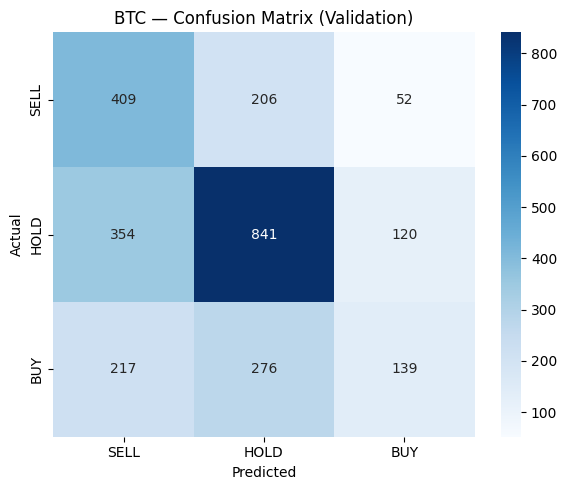

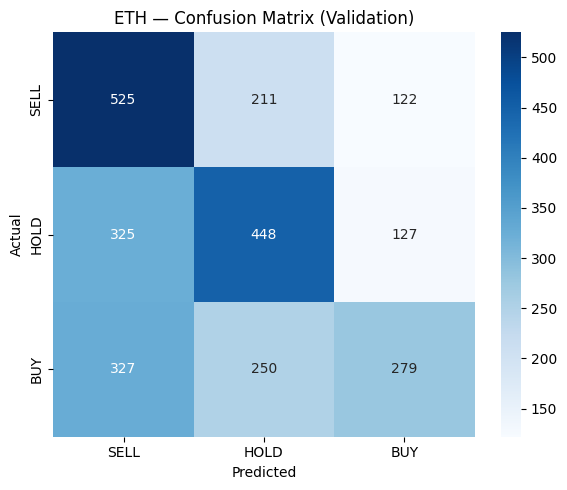

In [25]:
def plot_confusion(y_true, y_pred, name: str):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["SELL","HOLD","BUY"],
        yticklabels=["SELL","HOLD","BUY"],
        ax=ax
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{name} — Confusion Matrix (Validation)")
    plt.tight_layout()
    plt.savefig(os.path.join(MODELS_DIR, f"{name.lower()}_confusion_3class.png"), dpi=120)
    plt.show()

plot_confusion(btc["y_val"], btc_val_results["y_pred"], "BTC")
plot_confusion(eth["y_val"], eth_val_results["y_pred"], "ETH")

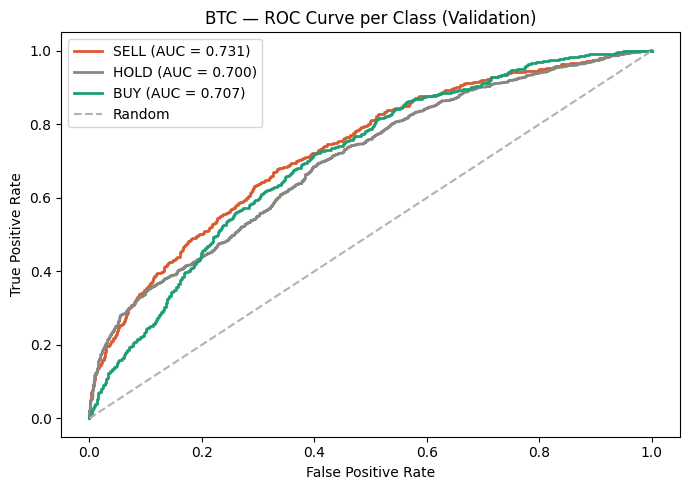

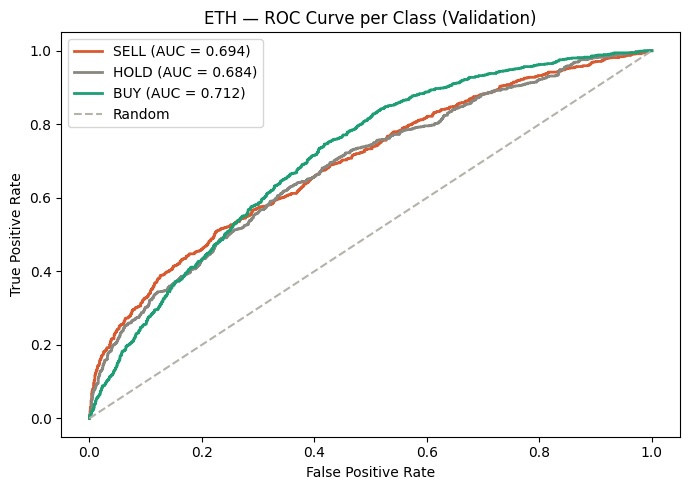

In [26]:
from sklearn.preprocessing import label_binarize
#9
def plot_roc_multiclass(y_true, y_prob, name: str):
    y_bin  = label_binarize(y_true, classes=[0, 1, 2])
    labels = ["SELL", "HOLD", "BUY"]
    colors = ["#D85A30", "#888780", "#1D9E75"]

    fig, ax = plt.subplots(figsize=(7, 5))
    for i, (label, color) in enumerate(zip(labels, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        auc_score   = roc_auc_score(y_bin[:, i], y_prob[:, i])
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f"{label} (AUC = {auc_score:.3f})")

    ax.plot([0,1],[0,1], color="#B4B2A9", linestyle="--", label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{name} — ROC Curve per Class (Validation)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(MODELS_DIR, f"{name.lower()}_roc_3class.png"), dpi=120)
    plt.show()

plot_roc_multiclass(btc["y_val"], btc_val_results["y_prob"], "BTC")
plot_roc_multiclass(eth["y_val"], eth_val_results["y_prob"], "ETH")

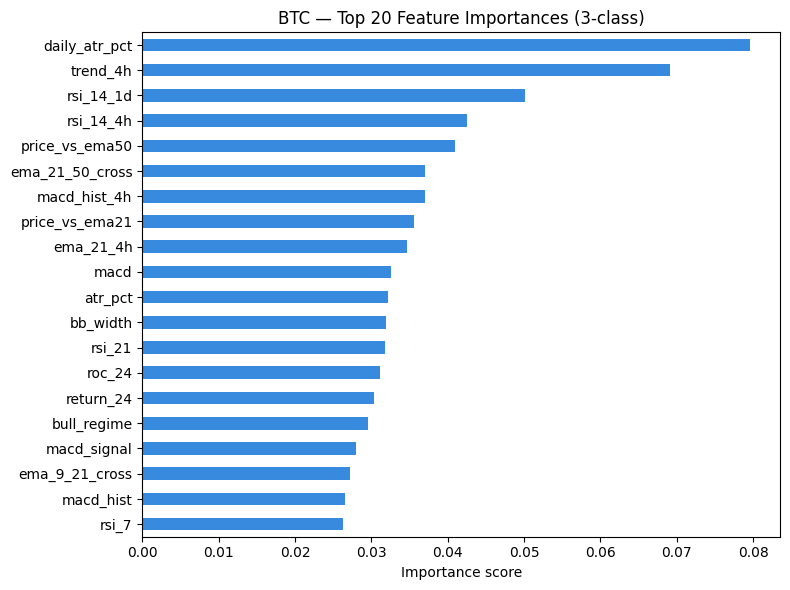


Top 5 features for BTC:
daily_atr_pct     0.079553
trend_4h          0.069113
rsi_14_1d         0.050178
rsi_14_4h         0.042511
price_vs_ema50    0.040958


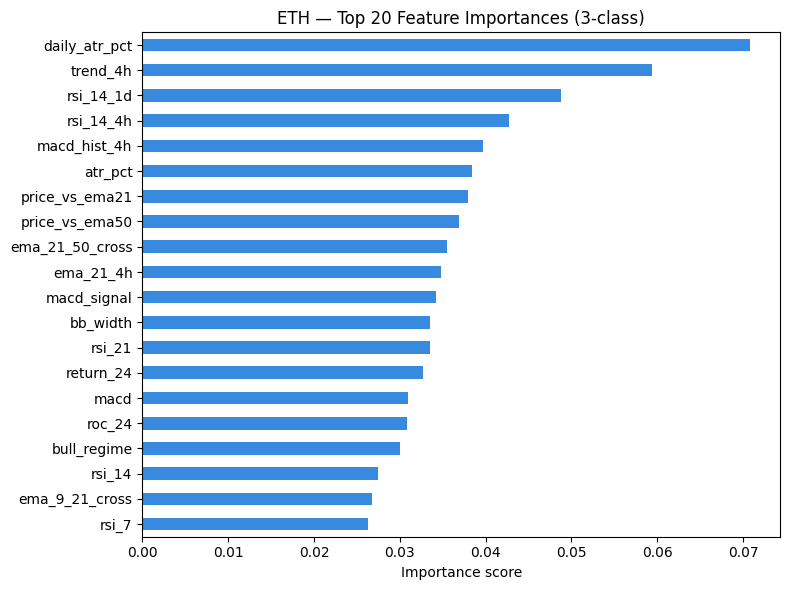


Top 5 features for ETH:
daily_atr_pct    0.070755
trend_4h         0.059326
rsi_14_1d        0.048751
rsi_14_4h        0.042735
macd_hist_4h     0.039663


In [27]:
def plot_feature_importance(model, feature_cols: list, name: str, top_n: int = 20):
    importance = pd.Series(
        model.feature_importances_,
        index=feature_cols
    ).sort_values(ascending=True).tail(top_n)

    fig, ax = plt.subplots(figsize=(8, 6))
    importance.plot(kind="barh", ax=ax, color="#378ADD")
    ax.set_title(f"{name} — Top {top_n} Feature Importances (3-class)")
    ax.set_xlabel("Importance score")
    plt.tight_layout()
    plt.savefig(os.path.join(MODELS_DIR, f"{name.lower()}_feature_importance_3class.png"), dpi=120)
    plt.show()

    print(f"\nTop 5 features for {name}:")
    print(importance.tail(5).sort_values(ascending=False).to_string())

plot_feature_importance(btc_xgb, feature_cols, "BTC")
plot_feature_importance(eth_xgb, feature_cols, "ETH")

In [28]:
#11
def train_lgb(data: dict, sample_weights, name: str):
    print(f"\nTraining LightGBM for {name}...")

    model = lgb.LGBMClassifier(
        n_estimators     = 500,
        max_depth        = 6,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        objective        = "multiclass",
        num_class        = 3,
        random_state     = 42,
        n_jobs           = -1,
        verbose          = -1,
    )

    model.fit(
        data["X_train"], data["y_train"],
        sample_weight = sample_weights,
        eval_set      = [(data["X_val"], data["y_val"])],
        callbacks     = [lgb.early_stopping(30), lgb.log_evaluation(50)]
    )

    return model

btc_lgb = train_lgb(btc, btc_sw, "BTC")
eth_lgb = train_lgb(eth, eth_sw, "ETH")

btc_lgb_results = evaluate(btc_lgb, btc, "BTC-LGB")
eth_lgb_results = evaluate(eth_lgb, eth, "ETH-LGB")


Training LightGBM for BTC...
Training until validation scores don't improve for 30 rounds
[50]	valid_0's multi_logloss: 0.968417
Early stopping, best iteration is:
[65]	valid_0's multi_logloss: 0.965413

Training LightGBM for ETH...
Training until validation scores don't improve for 30 rounds
[50]	valid_0's multi_logloss: 1.00665
[100]	valid_0's multi_logloss: 1.00368
Early stopping, best iteration is:
[75]	valid_0's multi_logloss: 1.00145


C:\Users\wizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\wizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  BTC-LGB | VAL SET RESULTS
              precision    recall  f1-score   support

    SELL (0)       0.40      0.60      0.48       667
    HOLD (1)       0.63      0.60      0.61      1315
     BUY (2)       0.39      0.23      0.29       632

    accuracy                           0.51      2614
   macro avg       0.47      0.47      0.46      2614
weighted avg       0.51      0.51      0.50      2614

  Macro F1          : 0.4598
  ROC-AUC (macro)   : 0.7034
  BUY  precision    : 0.3945  (365 signals)
  SELL precision    : 0.3954  (1009 signals)

  ETH-LGB | VAL SET RESULTS


C:\Users\wizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\wizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

    SELL (0)       0.45      0.59      0.51       858
    HOLD (1)       0.50      0.50      0.50       900
     BUY (2)       0.52      0.34      0.41       856

    accuracy                           0.48      2614
   macro avg       0.49      0.48      0.47      2614
weighted avg       0.49      0.48      0.47      2614

  Macro F1          : 0.4722
  ROC-AUC (macro)   : 0.6940
  BUY  precision    : 0.5160  (562 signals)
  SELL precision    : 0.4454  (1136 signals)


In [29]:
print("\n" + "="*55)
print("  MODEL COMPARISON — VALIDATION MACRO F1 + AUC")
print("="*55)
print(f"  BTC XGBoost   F1: {btc_val_results['f1']:.4f}   AUC: {btc_val_results['auc']:.4f}")
print(f"  BTC LightGBM  F1: {btc_lgb_results['f1']:.4f}   AUC: {btc_lgb_results['auc']:.4f}")
print()
print(f"  ETH XGBoost   F1: {eth_val_results['f1']:.4f}   AUC: {eth_val_results['auc']:.4f}")
print(f"  ETH LightGBM  F1: {eth_lgb_results['f1']:.4f}   AUC: {eth_lgb_results['auc']:.4f}")

btc_best      = btc_xgb  if btc_val_results["f1"] >= btc_lgb_results["f1"] else btc_lgb
eth_best      = eth_xgb  if eth_val_results["f1"] >= eth_lgb_results["f1"] else eth_lgb
btc_best_name = "XGBoost" if btc_val_results["f1"] >= btc_lgb_results["f1"] else "LightGBM"
eth_best_name = "XGBoost" if eth_val_results["f1"] >= eth_lgb_results["f1"] else "LightGBM"

print(f"\n  Winner BTC : {btc_best_name}")
print(f"  Winner ETH : {eth_best_name}")


  MODEL COMPARISON — VALIDATION MACRO F1 + AUC
  BTC XGBoost   F1: 0.4764   AUC: 0.7127
  BTC LightGBM  F1: 0.4598   AUC: 0.7034

  ETH XGBoost   F1: 0.4715   AUC: 0.6967
  ETH LightGBM  F1: 0.4722   AUC: 0.6940

  Winner BTC : XGBoost
  Winner ETH : LightGBM


In [30]:
#13
print("FINAL TEST SET EVALUATION\n")

btc_test_results = evaluate(btc_best, btc, f"BTC ({btc_best_name})", split="test")
eth_test_results = evaluate(eth_best, eth, f"ETH ({eth_best_name})", split="test")

print("\n" + "="*55)
print("  SUMMARY")
print("="*55)
print(f"  BTC test F1         : {btc_test_results['f1']:.4f}")
print(f"  BTC test AUC        : {btc_test_results['auc']:.4f}")
print(f"  BTC BUY  precision  : {btc_test_results['buy_precision']:.4f}")
print(f"  BTC SELL precision  : {btc_test_results['sell_precision']:.4f}")
print()
print(f"  ETH test F1         : {eth_test_results['f1']:.4f}")
print(f"  ETH test AUC        : {eth_test_results['auc']:.4f}")
print(f"  ETH BUY  precision  : {eth_test_results['buy_precision']:.4f}")
print(f"  ETH SELL precision  : {eth_test_results['sell_precision']:.4f}")

FINAL TEST SET EVALUATION


  BTC (XGBoost) | TEST SET RESULTS
              precision    recall  f1-score   support

    SELL (0)       0.41      0.72      0.52       721
    HOLD (1)       0.66      0.47      0.55      1197
     BUY (2)       0.56      0.38      0.45       697

    accuracy                           0.52      2615
   macro avg       0.54      0.53      0.51      2615
weighted avg       0.56      0.52      0.52      2615

  Macro F1          : 0.5075
  ROC-AUC (macro)   : 0.7211
  BUY  precision    : 0.5586  (478 signals)
  SELL precision    : 0.4053  (1288 signals)

  ETH (LightGBM) | TEST SET RESULTS


C:\Users\wizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\wizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

    SELL (0)       0.52      0.56      0.54       805
    HOLD (1)       0.56      0.55      0.55       999
     BUY (2)       0.50      0.48      0.49       810

    accuracy                           0.53      2614
   macro avg       0.53      0.53      0.53      2614
weighted avg       0.53      0.53      0.53      2614

  Macro F1          : 0.5263
  ROC-AUC (macro)   : 0.7222
  BUY  precision    : 0.5019  (775 signals)
  SELL precision    : 0.5192  (861 signals)

  SUMMARY
  BTC test F1         : 0.5075
  BTC test AUC        : 0.7211
  BTC BUY  precision  : 0.5586
  BTC SELL precision  : 0.4053

  ETH test F1         : 0.5263
  ETH test AUC        : 0.7222
  ETH BUY  precision  : 0.5019
  ETH SELL precision  : 0.5192


In [31]:
#14
def save_model(model, name: str):
    path = os.path.join(MODELS_DIR, f"{name}_best_model.pkl")
    with open(path, "wb") as f:
        pickle.dump(model, f)
    size = os.path.getsize(path) / 1024
    print(f"Saved: {path}  ({size:.1f} KB)")

save_model(btc_best, "btc")
save_model(eth_best, "eth")

summary = {
    "btc_model"          : btc_best_name,
    "eth_model"          : eth_best_name,
    "btc_val_f1"         : btc_val_results["f1"],
    "btc_test_f1"        : btc_test_results["f1"],
    "btc_test_auc"       : btc_test_results["auc"],
    "btc_buy_precision"  : btc_test_results["buy_precision"],
    "btc_sell_precision" : btc_test_results["sell_precision"],
    "eth_val_f1"         : eth_val_results["f1"],
    "eth_test_f1"        : eth_test_results["f1"],
    "eth_test_auc"       : eth_test_results["auc"],
    "eth_buy_precision"  : eth_test_results["buy_precision"],
    "eth_sell_precision" : eth_test_results["sell_precision"],
}

summary_path = os.path.join(MODELS_DIR, "phase3_summary_3class.pkl")
with open(summary_path, "wb") as f:
    pickle.dump(summary, f)

print("\nPhase 3 (3-class) complete. Ready for Phase 4.")


Saved: ./data/models\btc_best_model.pkl  (1898.1 KB)
Saved: ./data/models\eth_best_model.pkl  (761.9 KB)

Phase 3 (3-class) complete. Ready for Phase 4.


In [34]:
def find_best_threshold_3class(model, data: dict, name: str):
    """
    For 3-class model we threshold on raw probabilities per class.
    prob[:,0] = SELL probability
    prob[:,2] = BUY  probability
    We find the threshold that maximises precision for each direction.
    """
    y_prob = model.predict_proba(data["X_val"])
    y_true = data["y_val"]

    prob_buy  = y_prob[:, 2]
    prob_sell = y_prob[:, 0]

    print(f"\n{name} — BUY threshold analysis:")
    print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'Signals':>10}")
    print("-" * 45)
    for thresh in [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]:
        mask = prob_buy >= thresh
        if mask.sum() == 0:
            continue
        p = (y_true[mask] == 2).mean()
        r = ((y_true == 2) & mask).sum() / (y_true == 2).sum()
        print(f"{thresh:>10.2f} {p:>10.3f} {r:>10.3f} {mask.sum():>10}")

    print(f"\n{name} — SELL threshold analysis:")
    print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'Signals':>10}")
    print("-" * 45)
    for thresh in [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]:
        mask = prob_sell >= thresh
        if mask.sum() == 0:
            continue
        p = (y_true[mask] == 0).mean()
        r = ((y_true == 0) & mask).sum() / (y_true == 0).sum()
        print(f"{thresh:>10.2f} {p:>10.3f} {r:>10.3f} {mask.sum():>10}")

find_best_threshold_3class(btc_best, btc, "BTC")
find_best_threshold_3class(eth_best, eth, "ETH")


BTC — BUY threshold analysis:
 Threshold  Precision     Recall    Signals
---------------------------------------------
      0.35      0.417      0.271        410
      0.40      0.449      0.207        292
      0.45      0.489      0.147        190
      0.50      0.521      0.098        119
      0.55      0.573      0.068         75
      0.60      0.535      0.036         43
      0.65      0.619      0.021         21

BTC — SELL threshold analysis:
 Threshold  Precision     Recall    Signals
---------------------------------------------
      0.35      0.395      0.696       1176
      0.40      0.422      0.610        964
      0.45      0.449      0.535        795
      0.50      0.487      0.469        643
      0.55      0.510      0.403        527
      0.60      0.570      0.319        374
      0.65      0.624      0.246        263


C:\Users\wizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



ETH — BUY threshold analysis:
 Threshold  Precision     Recall    Signals
---------------------------------------------
      0.35      0.517      0.419        694
      0.40      0.525      0.298        486
      0.45      0.547      0.210        329
      0.50      0.596      0.148        213
      0.55      0.611      0.093        131
      0.60      0.632      0.056         76
      0.65      0.634      0.030         41

ETH — SELL threshold analysis:
 Threshold  Precision     Recall    Signals
---------------------------------------------
      0.35      0.438      0.700       1372
      0.40      0.466      0.580       1069
      0.45      0.506      0.463        784
      0.50      0.567      0.392        593
      0.55      0.649      0.310        410
      0.60      0.712      0.233        281
      0.65      0.762      0.168        189
